In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import seaborn as sns

names_bw=['time', 'bw', 'op1', 'size', 'op2' ]
names_latency=['time', 'latency', 'op2', 'write_size', 'op3']

/tmp/ipykernel_85923/2843940828.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_transferred_per_interval = df.groupby('time_bin')['write_size'].sum()


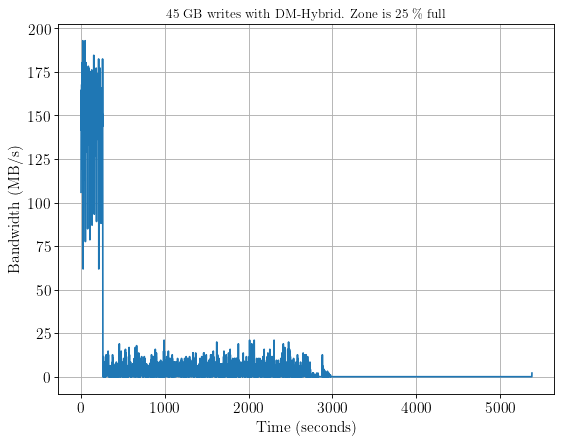

/tmp/ipykernel_85923/2843940828.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_transferred_per_interval = df.groupby('time_bin')['write_size'].sum()


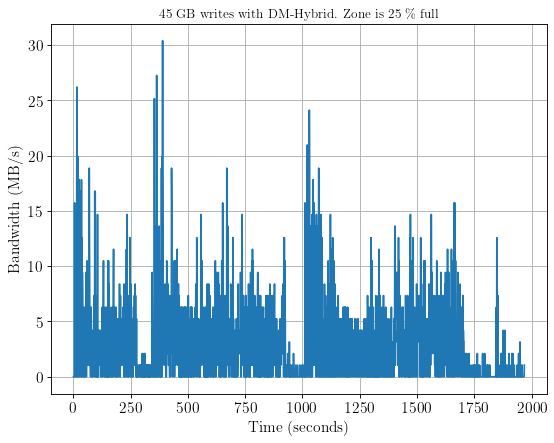

/tmp/ipykernel_85923/2843940828.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_transferred_per_interval = df.groupby('time_bin')['write_size'].sum()


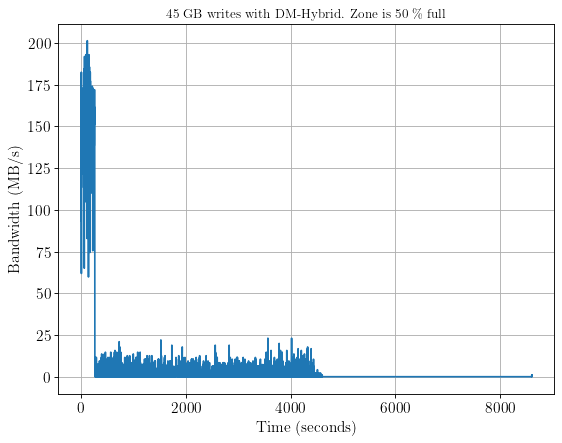

/tmp/ipykernel_85923/2843940828.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_transferred_per_interval = df.groupby('time_bin')['write_size'].sum()


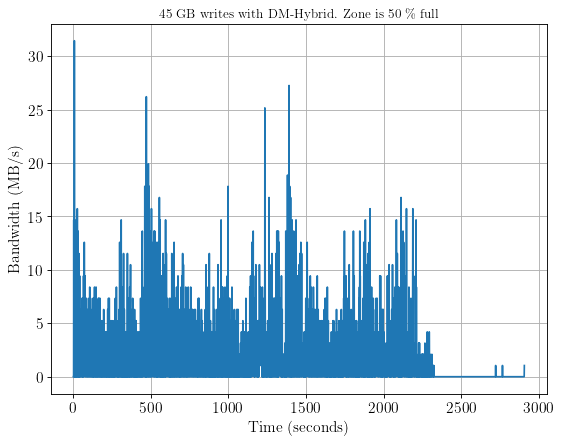

/tmp/ipykernel_85923/2843940828.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_transferred_per_interval = df.groupby('time_bin')['write_size'].sum()


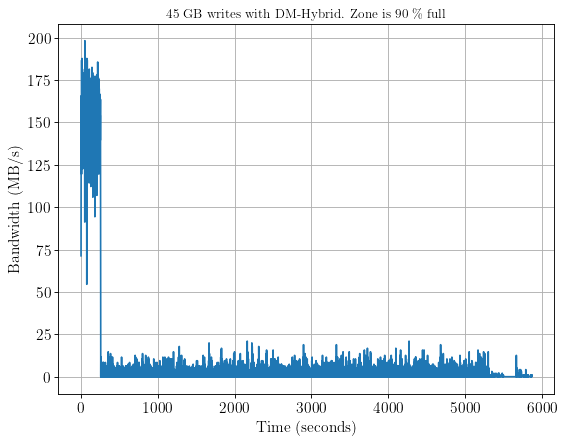

/tmp/ipykernel_85923/2843940828.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_transferred_per_interval = df.groupby('time_bin')['write_size'].sum()


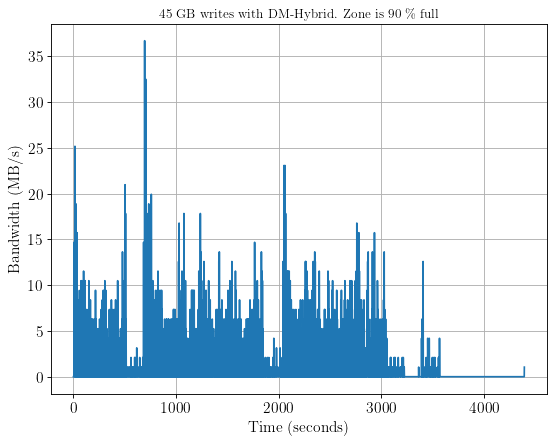

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file
names_latency=['generation_time_sec', 'completion_time_ns', 'op2', 'write_size', 'op3']
dirs = ["25Util", "50Util", "90Util"]
runs = ["run1", "run2"]
for dir in dirs:
  for run in runs:
    df = pd.read_csv(f'/home/surbhi/measurements/worst_case/STL/1M/90-10-LBA/{dir}/{run}/lat_log_avg_lat.1.log', names=names_latency)
    df['generation_time_sec'] = df['generation_time_sec'] - df.iloc[0].generation_time_sec
    # Convert generation time from milliseconds to seconds
    df['generation_time_sec'] = df['generation_time_sec'] / 1000.0

    # Convert completion time from nanoseconds to seconds
    df['completion_time_sec'] = df['generation_time_sec'] + (df['completion_time_ns'] / 1e9)
    # Bin the data into 1-second intervals and calculate the total amount of data transferred in each interval
    df['time_bin'] = pd.cut(df['completion_time_sec'], bins=range(int(df['completion_time_sec'].max()) + 2), right=False)
    data_transferred_per_interval = df.groupby('time_bin')['write_size'].sum()

    # Calculate the instantaneous bandwidth for each interval (in MB/sec)
    bandwidth_per_interval = data_transferred_per_interval / 1e6  # Convert bytes to megabytes
    # bandwidth_per_interval /= 1  # Convert seconds to 1-second intervals

    # print(bandwidth_per_interval)

    # Plot the instantaneous bandwidth over time
    #get the interval edges and values
    x = bandwidth_per_interval.index
    y = bandwidth_per_interval.values

    #get right edge of the interval
    x = [i.right for i in x]

    plt.figure(figsize=(8, 6), dpi=80)
    plt.rc('text', usetex=True)
    plt.rc('font', family='serif')
    plt.rcParams['pdf.fonttype'] = 42
    plt.rcParams['ps.fonttype'] = 42

    plt.plot(x, y)
    # xticks = np.arange(0, math.ceil(max(x)), 50)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.xlabel('Time (seconds)', fontsize=14)
    plt.ylabel('Bandwidth (MB/s)', fontsize=14)

    plt.grid(True)  # Optionally, add grid lines
    name=dir.split("Util")
    plt.title(f"45 GB writes with DM-Hybrid. Zone is {name[0]} \% full")
    plt.savefig(f'/home/surbhi/github/surbhi-plots/new/STL/{dir}_{run}.png', bbox_inches='tight')
    plt.show()


/tmp/ipykernel_85923/1530140987.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_transferred_per_interval = df.groupby('time_bin')['write_size'].sum()


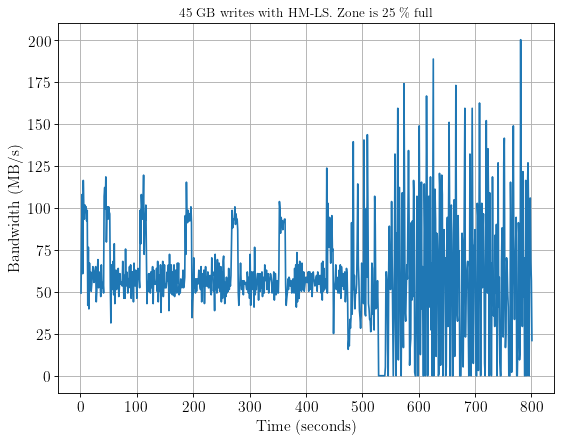

/tmp/ipykernel_85923/1530140987.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_transferred_per_interval = df.groupby('time_bin')['write_size'].sum()


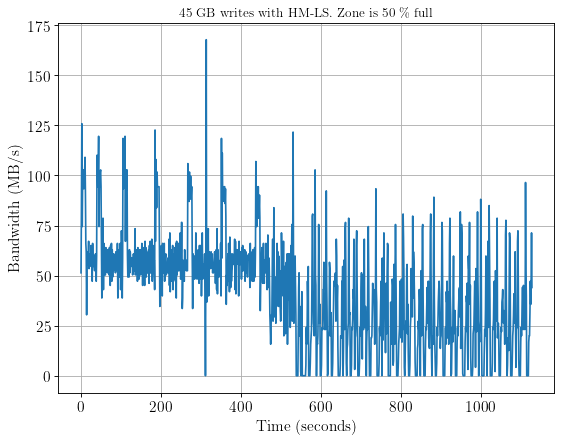

/tmp/ipykernel_85923/1530140987.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_transferred_per_interval = df.groupby('time_bin')['write_size'].sum()


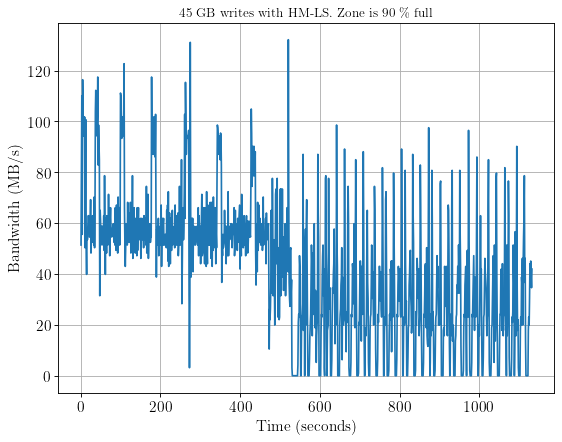

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file
names_latency=['generation_time_sec', 'completion_time_ns', 'op2', 'write_size', 'op3']
dirs = ["25Util", "50Util", "90Util"]
runs = ["run1", "run2"]
for dir in dirs:
  #/home/surbhi/measurements/worst_case/lsdm/lsdm-util/25Util/1MB/8TB/90-10-LBA/45GB
  df = pd.read_csv(f'/home/surbhi/measurements/worst_case/lsdm/lsdm-util/{dir}/1MB/8TB/90-10-LBA/45GB/lat_log_avg_lat.1.log', names=names_latency)
  df['generation_time_sec'] = df['generation_time_sec'] - df.iloc[0].generation_time_sec
  # Convert generation time from milliseconds to seconds
  df['generation_time_sec'] = df['generation_time_sec'] / 1000.0

  # Convert completion time from nanoseconds to seconds
  df['completion_time_sec'] = df['generation_time_sec'] + (df['completion_time_ns'] / 1e9)
  # Bin the data into 1-second intervals and calculate the total amount of data transferred in each interval
  df['time_bin'] = pd.cut(df['completion_time_sec'], bins=range(int(df['completion_time_sec'].max()) + 2), right=False)
  data_transferred_per_interval = df.groupby('time_bin')['write_size'].sum()

  # Calculate the instantaneous bandwidth for each interval (in MB/sec)
  bandwidth_per_interval = data_transferred_per_interval / 1e6  # Convert bytes to megabytes
  # bandwidth_per_interval /= 1  # Convert seconds to 1-second intervals

  # print(bandwidth_per_interval)

  # Plot the instantaneous bandwidth over time
  #get the interval edges and values
  x = bandwidth_per_interval.index
  y = bandwidth_per_interval.values

  #get right edge of the interval
  x = [i.right for i in x]

  plt.figure(figsize=(8, 6), dpi=80)
  plt.rc('text', usetex=True)
  plt.rc('font', family='serif')
  plt.rcParams['pdf.fonttype'] = 42
  plt.rcParams['ps.fonttype'] = 42
  

  plt.plot(x, y)
  # xticks = np.arange(0, math.ceil(max(x)), 50)
  plt.xticks(fontsize=14)
  plt.yticks(fontsize=14)
  plt.xlabel('Time (seconds)', fontsize=14)
  plt.ylabel('Bandwidth (MB/s)', fontsize=14)

  plt.grid(True)  # Optionally, add grid lines
  name=dir.split("Util")
  plt.title(f"45 GB writes with HM-LS. Zone is {name[0]} \% full")
  plt.savefig(f'/home/surbhi/github/surbhi-plots/new/LSDM/{dir}.png', bbox_inches='tight')  
  plt.show()
